# PHÂN TÍCH DỮ LIỆU KHÁM PHÁ (EDA) - DATASET MUSIC GENRE CLASSIFICATION

## 1. Định nghĩa vấn đề

- **Training dataset**: 14395 rows with 18 columns

- **Column details**: artist name; track name; popularity; ‘danceability’; energy; key; loudness; mode; ‘speechiness’; ‘acousticness’; ‘instrumentalness’; liveness; valence; tempo; duration in milliseconds and time_signature.

- **Target Variable**: 'Class’ such as Rock, Indie, Alt, Pop, Metal, HipHop, Alt_Music, Blues, Acoustic/Folk, Instrumental, Country, Bollywood,

- **Test dataset**: 3600 rows with 17 columns

## 2. Chuẩn bị vấn đề

### 2.1. Khai báo thư viện

In [2]:
# %load_ext autoreload
%reload_ext autoreload
%autoreload 2

# Import các thư viện cần thiết
import pandas as pd
import sys, os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython import display

# Thiết lập
import warnings
warnings.filterwarnings('ignore')
data_dir = '../../data/music-genre'
print("Đã import thành công các thư viện cần thiết!")

Đã import thành công các thư viện cần thiết!


### 2.2. Nạp dữ liệu

In [3]:
train_df = pd.read_csv(f'{data_dir}/train (1).csv')
test_df = pd.read_csv(f'{data_dir}/test (2).csv')
df = pd.concat([train_df, test_df], ignore_index=True)
print("Đã load dữ liệu thành công!")

Đã load dữ liệu thành công!


## 3. Phân tích dữ liệu

### 3.1. Thống kê mô tả

#### (1) **Hiển thị một số thông tin về dữ liệu**
+ Số dòng, số cột của dữ liệu
+ Kiểu dữ liệu của từng cột
+ 5 dòng đầu
+ Thông tin chung về dữ liệu

In [4]:
print(f"- Shape: {df.shape}")
print(f"- Types:\n{df.dtypes}")
print("- Header(5):")
display.display(df.head())
print(f"- Info:\n{df.info()}")

- Shape: (17996, 18)
- Types:
Id                      int64
Artist Name            object
Track Name             object
Popularity            float64
danceability          float64
energy                float64
key                   float64
loudness              float64
mode                    int64
speechiness           float64
acousticness          float64
instrumentalness      float64
liveness              float64
valence               float64
tempo                 float64
duration_in min/ms    float64
time_signature          int64
Class                 float64
dtype: object
- Header(5):


,Id,Artist Name,Track Name,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature,Class
0,1,Marina Maximilian,Not Afraid,37.0,0.334,0.536,9.0,-6.649,0,0.0381,0.378000,NaN,0.106,0.235,152.429,204947.0,4,9.0
1,2,The Black Keys,Howlin' for You,67.0,0.725,0.747,11.0,-5.545,1,0.0876,0.027200,0.0468,0.104,0.380,132.921,191956.0,4,6.0
2,3,Royal & the Serpent,phuck u,NaN,0.584,0.804,7.0,-6.094,1,0.0619,0.000968,0.6350,0.284,0.635,159.953,161037.0,4,10.0
3,4,Detroit Blues Band,Missing You,12.0,0.515,0.308,NaN,-14.711,1,0.0312,0.907000,0.0213,0.300,0.501,172.472,298093.0,3,2.0
4,5,Coast Contra,My Lady,48.0,0.565,0.777,6.0,-5.096,0,0.2490,0.183000,NaN,0.211,0.619,88.311,254145.0,4,5.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17996 entries, 0 to 17995
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Id                  17996 non-null  int64  
 1   Artist Name         17996 non-null  object 
 2   Track Name          17996 non-null  object 
 3   Popularity          17568 non-null  float64
 4   danceability        17996 non-null  float64
 5   energy              17996 non-null  float64
 6   key                 15982 non-null  float64
 7   loudness            17996 non-null  float64
 8   mode                17996 non-null  int64  
 9   speechiness         17996 non-null  float64
 10  acousticness        17996 non-null  float64
 11  instrumentalness    13619 non-null  float64
 12  liveness            17996 non-null  float64
 13  valence             17996 non-null  float64
 14  tempo               17996 non-null  float64
 15  duration_in min/ms  17996 non-null  float64
 16  time

#### (2) **Kiểm tra tính toàn vẹn của dữ liệu**

In [5]:
print("-"*10, "Missing Values", "-"*10)
def missing_values_info(df):
    missing_data = df.isnull().sum()
    missing_percent = (missing_data / len(df)) * 100
    missing_df = pd.DataFrame({
        'Cột': missing_data.index,
        'Số lượng thiếu': missing_data.values,
        'Tỷ lệ % thiếu': missing_percent.values
    })
    missing_df = missing_df[missing_df['Số lượng thiếu'] > 0].sort_values('Số lượng thiếu', ascending=False)
    return missing_df

display.display(missing_values_info(train_df))

print("-"*10, "Duplicate Rows", "-"*10)
print(f"{df.duplicated().sum()}")

---------- Missing Values ----------


,Cột,Số lượng thiếu,Tỷ lệ % thiếu
11,instrumentalness,3541,24.597110
6,key,1609,11.176716
3,Popularity,333,2.313143


---------- Duplicate Rows ----------
0


#### (3) **Các tính chất thống kê trên dữ liệu số**
+ Count, Mean, Standard Deviation, Minimum Value
+ 25th Percentile, 50th Percentile (Median), 75th Percentile, Maximum Value

In [6]:
print("-"*10, "Statistical Summary of Numerical Features", "-"*10)
display.display(df.describe().T)

---------- Statistical Summary of Numerical Features ----------


,count,mean,std,min,25%,50%,75%,max
Id,17996.0,8998.500000,5195.142058,1.000000,4499.750000,8998.50000,13497.25000,17996.000
Popularity,17568.0,44.512124,17.426928,1.000000,33.000000,44.00000,56.00000,100.000
danceability,17996.0,0.543433,0.166268,0.059600,0.432000,0.54500,0.65900,0.989
energy,17996.0,0.662777,0.235373,0.000020,0.509000,0.70000,0.86000,1.000
key,15982.0,5.952447,3.196854,1.000000,3.000000,6.00000,9.00000,11.000
loudness,17996.0,-7.910660,4.049151,-39.952000,-9.538000,-7.01600,-5.18900,1.355
mode,17996.0,0.636753,0.480949,0.000000,0.000000,1.00000,1.00000,1.000
speechiness,17996.0,0.079707,0.083576,0.022500,0.034800,0.04740,0.08300,0.955
acousticness,17996.0,0.247082,0.310632,0.000000,0.004300,0.08140,0.43400,0.996
instrumentalness,13619.0,0.177562,0.304048,0.000001,0.000089,0.00391,0.20000,0.996


#### (4) **Tần suất xuất hiện trên dữ liệu phân lớp**

In [7]:
print("- Count")
display.display(df['Class'].value_counts())
print("- Proportion")
display.display(df['Class'].value_counts(normalize=True))

- Count


Class
10.0    3959
6.0     2069
9.0     2019
8.0     1483
5.0     1157
1.0     1098
2.0     1018
0.0      500
7.0      461
3.0      322
4.0      310
Name: count, dtype: int64

- Proportion


Class
10.0    0.275007
6.0     0.143720
9.0     0.140247
8.0     0.103015
5.0     0.080370
1.0     0.076271
2.0     0.070714
0.0     0.034732
7.0     0.032023
3.0     0.022367
4.0     0.021534
Name: proportion, dtype: float64

**Nhận xét**<br>
*Thêm nhận xét ở đây*

#### (5) **Mối tương quan giữa các tính chất (Correlations)**

In [8]:
correlations = train_df.drop(columns=['Id', 'Artist Name', 'Track Name'], axis=1).corr()
display.display(correlations)

,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature,Class
Popularity,1.000000,0.172907,0.051820,0.010230,0.124621,0.013747,0.029297,-0.128886,-0.165232,-0.068159,0.054741,-0.002964,-0.027773,0.070232,0.159484
danceability,0.172907,1.000000,-0.094806,0.007667,0.056193,-0.069311,0.202985,0.007414,-0.203278,-0.105949,0.444798,-0.180764,-0.127245,0.137127,-0.101152
energy,0.051820,-0.094806,1.000000,0.012834,0.769586,-0.035974,0.120869,-0.746436,-0.187964,0.197802,0.227542,0.205421,0.241190,0.142971,0.215611
key,0.010230,0.007667,0.012834,1.000000,0.005738,-0.113318,0.001133,-0.007678,-0.001255,0.014747,0.031505,0.019937,0.014343,0.008123,-0.004175
loudness,0.124621,0.056193,0.769586,0.005738,1.000000,-0.030553,0.090473,-0.614967,-0.350667,0.113663,0.185779,0.161750,0.169003,0.125978,0.174111
mode,0.013747,-0.069311,-0.035974,-0.113318,-0.030553,1.000000,-0.072489,0.020817,-0.019665,-0.002697,-0.007580,0.017616,-0.070849,-0.016817,-0.040092
speechiness,0.029297,0.202985,0.120869,0.001133,0.090473,-0.072489,1.000000,-0.084849,-0.065775,0.072569,0.059227,0.049739,0.006253,0.055992,-0.062784
acousticness,-0.128886,0.007414,-0.746436,-0.007678,-0.614967,0.020817,-0.084849,1.000000,0.182656,-0.109400,-0.127707,-0.162988,-0.321357,-0.139500,-0.240609
instrumentalness,-0.165232,-0.203278,-0.187964,-0.001255,-0.350667,-0.019665,-0.065775,0.182656,1.000000,-0.049089,-0.228681,-0.036254,-0.010012,-0.067573,-0.028631
liveness,-0.068159,-0.105949,0.197802,0.014747,0.113663,-0.002697,0.072569,-0.109400,-0.049089,1.000000,0.027385,0.030776,0.046579,0.014825,0.040101


### 3.2. Hiển thị dữ liệu

#### (1) **Hiển thị trên từng tính chất đơn**

##### Species

<Axes: xlabel='Class', ylabel='count'>

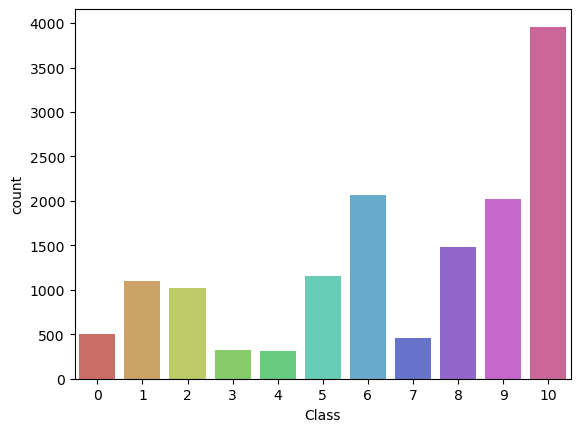

In [9]:
sns.countplot(data=train_df, x='Class', palette='hls')

##### Count Plots

Khai báo các cột dữ liệu số

In [10]:
numerical_cols = df.drop(columns=['Id', 'Class']).select_dtypes(include=np.number).columns.tolist()
print(f"Numerical columns: {numerical_cols}")

Numerical columns: ['Popularity', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_in min/ms', 'time_signature']


##### Box Plots

Popularity               Axes(0.125,0.712609;0.168478x0.167391)
danceability          Axes(0.327174,0.712609;0.168478x0.167391)
energy                Axes(0.529348,0.712609;0.168478x0.167391)
key                   Axes(0.731522,0.712609;0.168478x0.167391)
loudness                 Axes(0.125,0.511739;0.168478x0.167391)
mode                  Axes(0.327174,0.511739;0.168478x0.167391)
speechiness           Axes(0.529348,0.511739;0.168478x0.167391)
acousticness          Axes(0.731522,0.511739;0.168478x0.167391)
instrumentalness          Axes(0.125,0.31087;0.168478x0.167391)
liveness               Axes(0.327174,0.31087;0.168478x0.167391)
valence                Axes(0.529348,0.31087;0.168478x0.167391)
tempo                  Axes(0.731522,0.31087;0.168478x0.167391)
duration_in min/ms           Axes(0.125,0.11;0.168478x0.167391)
time_signature            Axes(0.327174,0.11;0.168478x0.167391)
dtype: object

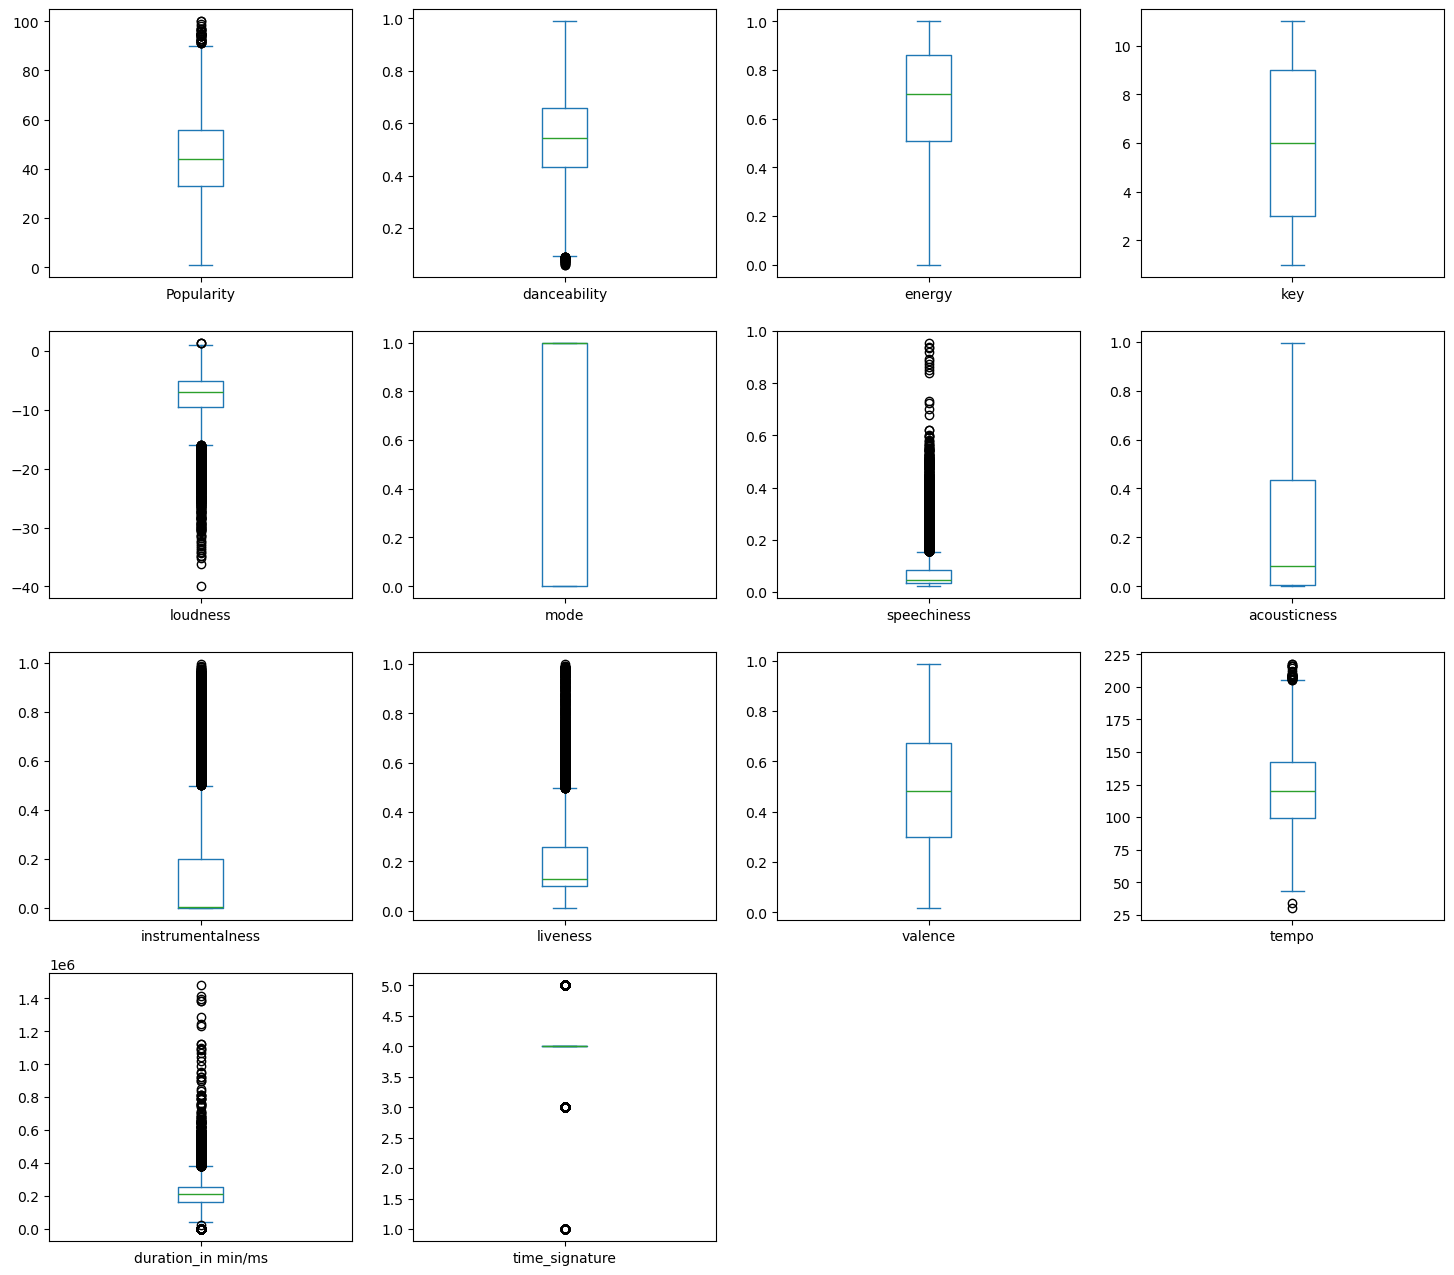

In [11]:
df[numerical_cols].plot(kind="box", subplots=True, layout=(4, 4), sharex=False, sharey=False, figsize=(18, 16))

##### Histogram

array([[<Axes: title={'center': 'Popularity'}>,
        <Axes: title={'center': 'danceability'}>,
        <Axes: title={'center': 'energy'}>,
        <Axes: title={'center': 'key'}>],
       [<Axes: title={'center': 'loudness'}>,
        <Axes: title={'center': 'mode'}>,
        <Axes: title={'center': 'speechiness'}>,
        <Axes: title={'center': 'acousticness'}>],
       [<Axes: title={'center': 'instrumentalness'}>,
        <Axes: title={'center': 'liveness'}>,
        <Axes: title={'center': 'valence'}>,
        <Axes: title={'center': 'tempo'}>],
       [<Axes: title={'center': 'duration_in min/ms'}>,
        <Axes: title={'center': 'time_signature'}>, <Axes: >, <Axes: >]],
      dtype=object)

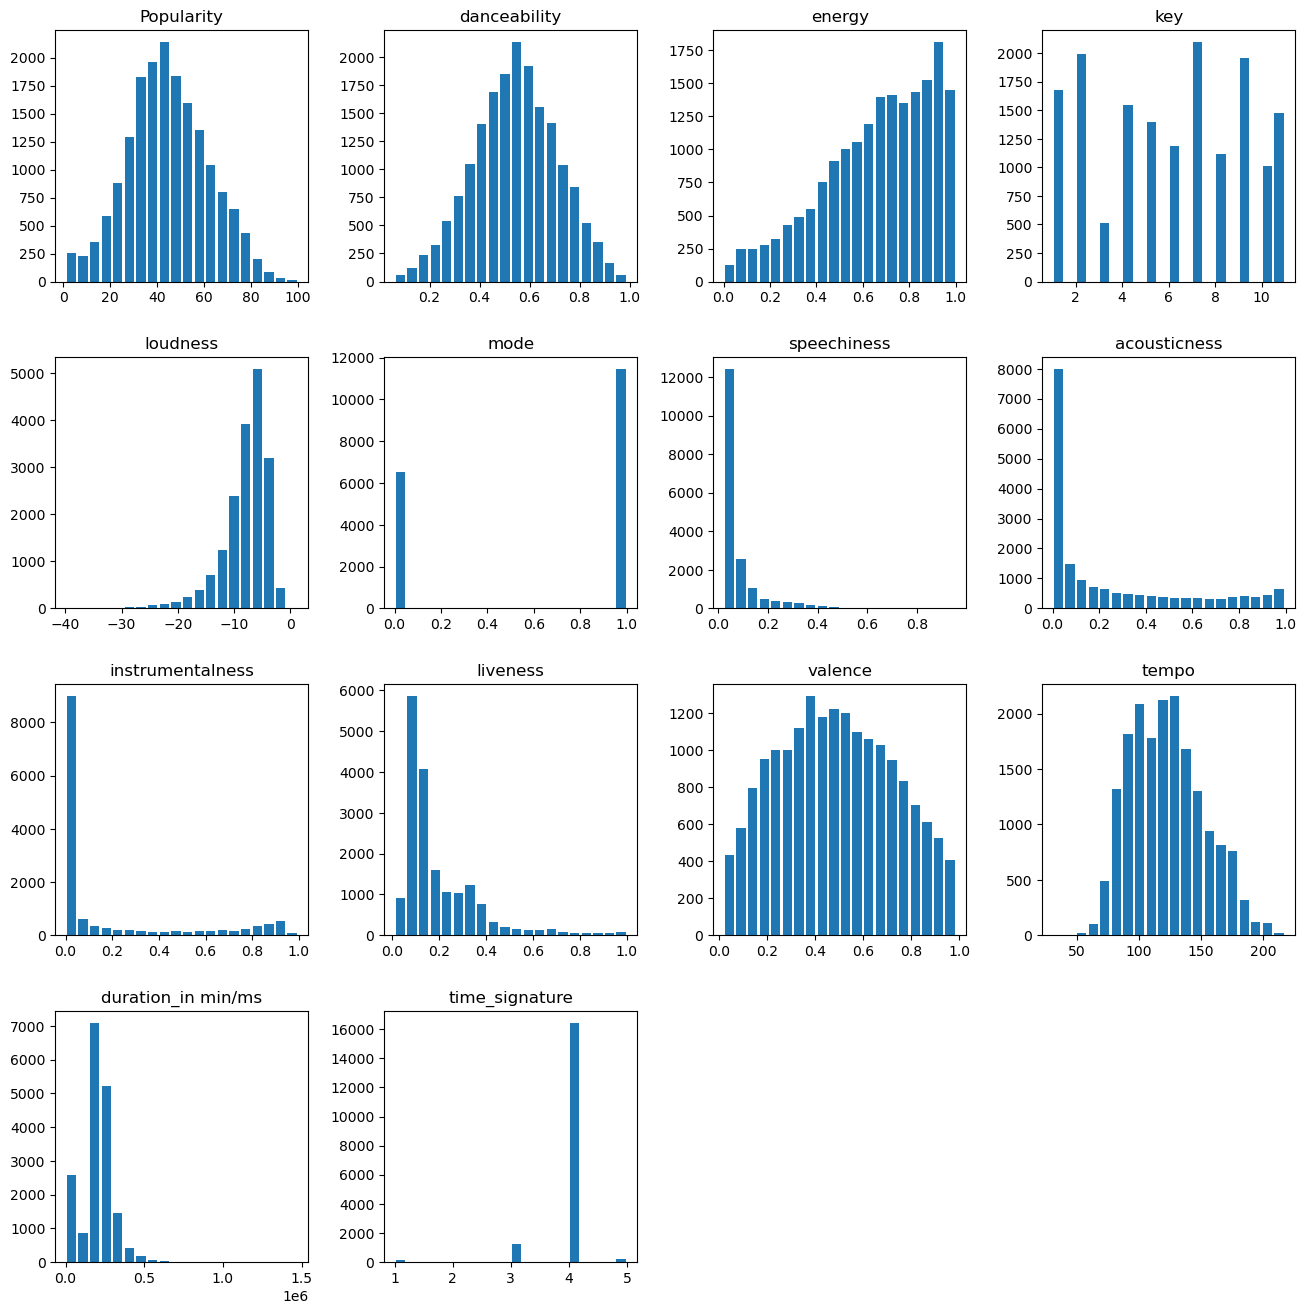

In [12]:
df[numerical_cols].hist(figsize=(16, 16), grid=False, rwidth=0.8, bins=20)

##### Density Plots

array([[<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>, <Axes: ylabel='Density'>],
       [<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>, <Axes: ylabel='Density'>],
       [<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>, <Axes: ylabel='Density'>],
       [<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>, <Axes: ylabel='Density'>]], dtype=object)

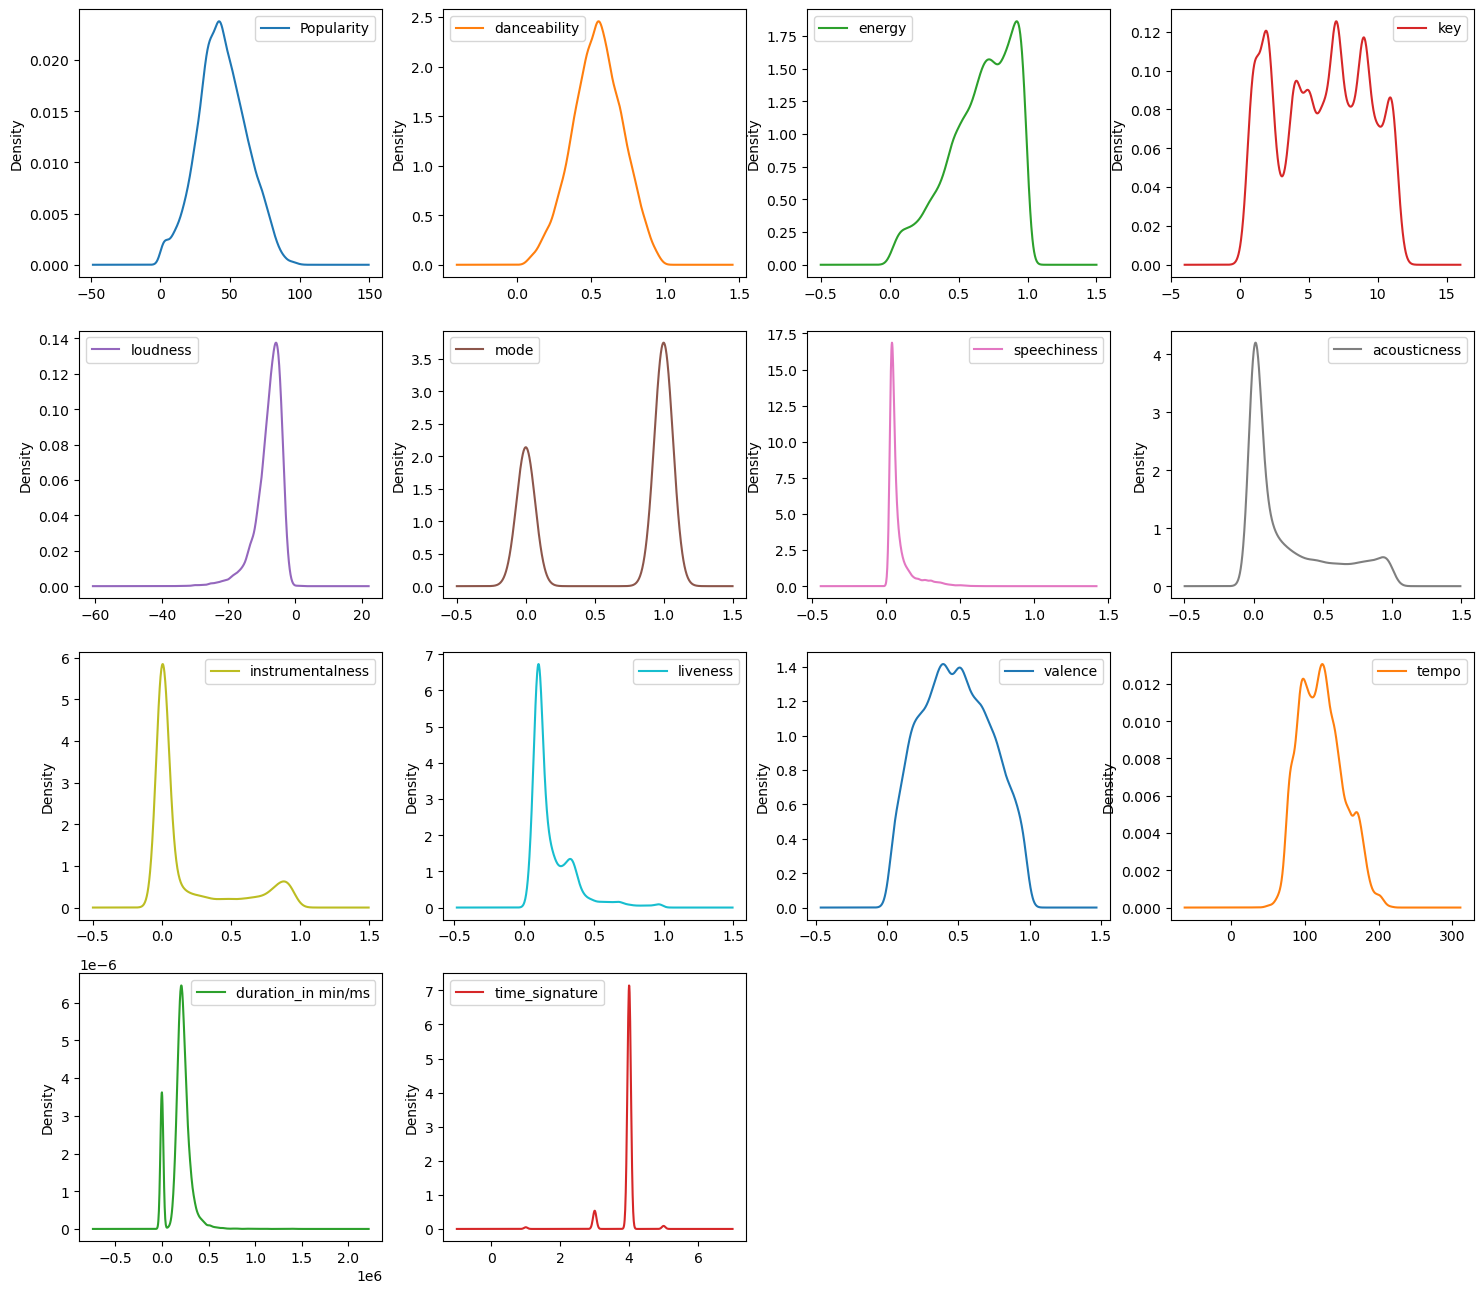

In [13]:
df[numerical_cols].plot(kind="density", subplots=True, layout=(4, 4), sharex=False, sharey=False, figsize=(18, 16))

#### (2) **Hiển thị nhiều tính chất**

##### Box Plots

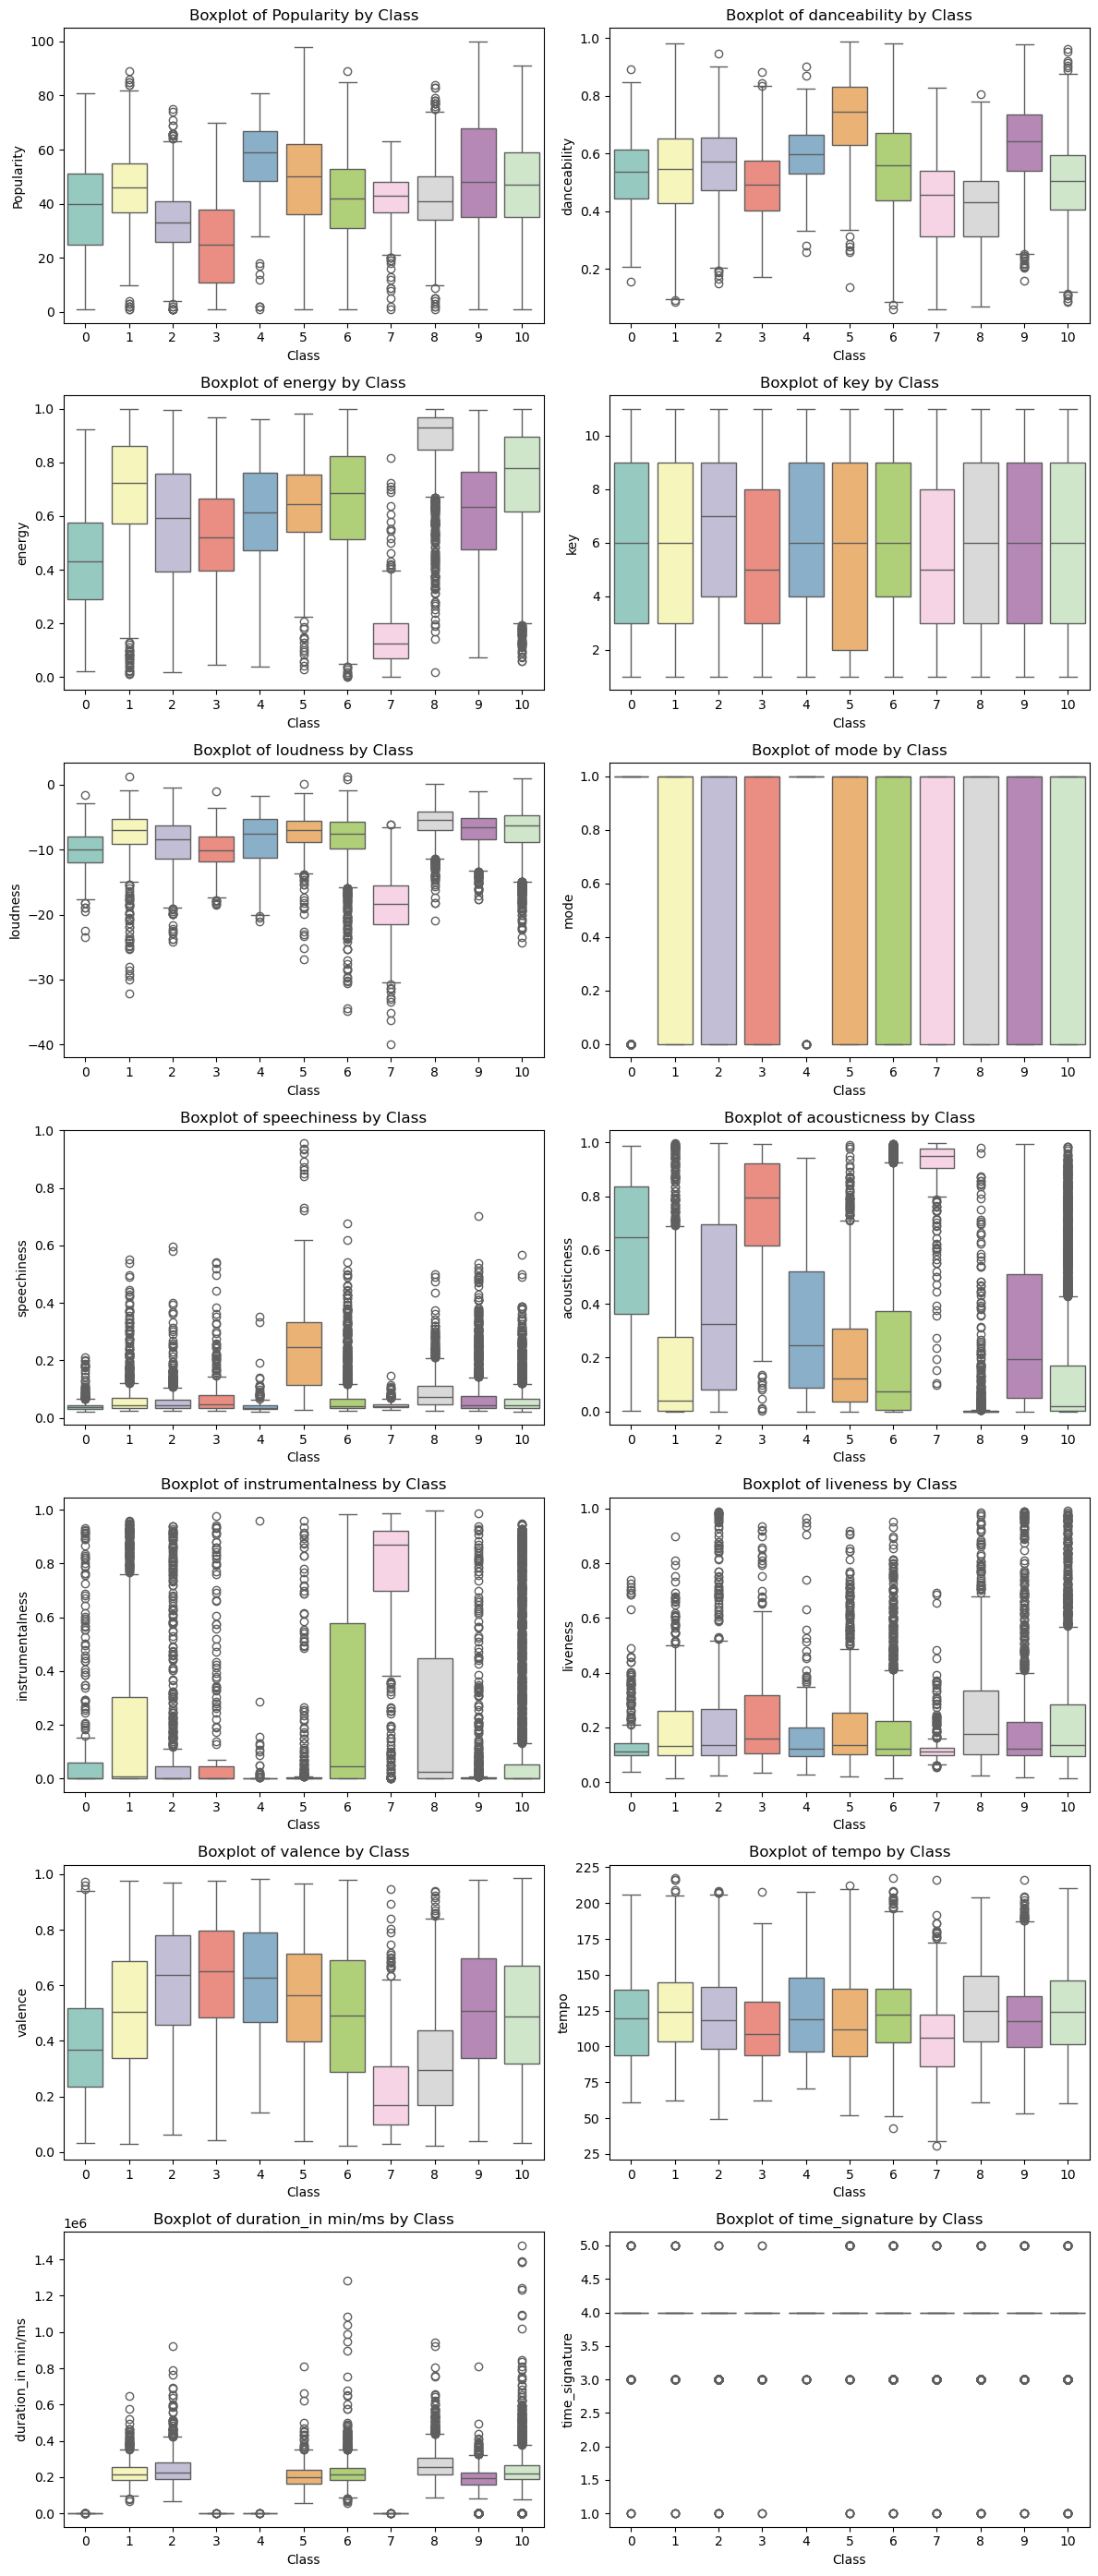

In [14]:
fig, axes = plt.subplots(7, 2, figsize=(12, 28))

for i, col in enumerate(numerical_cols):
    sns.boxplot(x='Class', y=col, data=train_df, ax=axes[i//2, i%2], palette='Set3')
    axes[i//2, i%2].set_title(f'Boxplot of {col} by Class')
    
plt.tight_layout()

##### Heatmap

<Axes: >

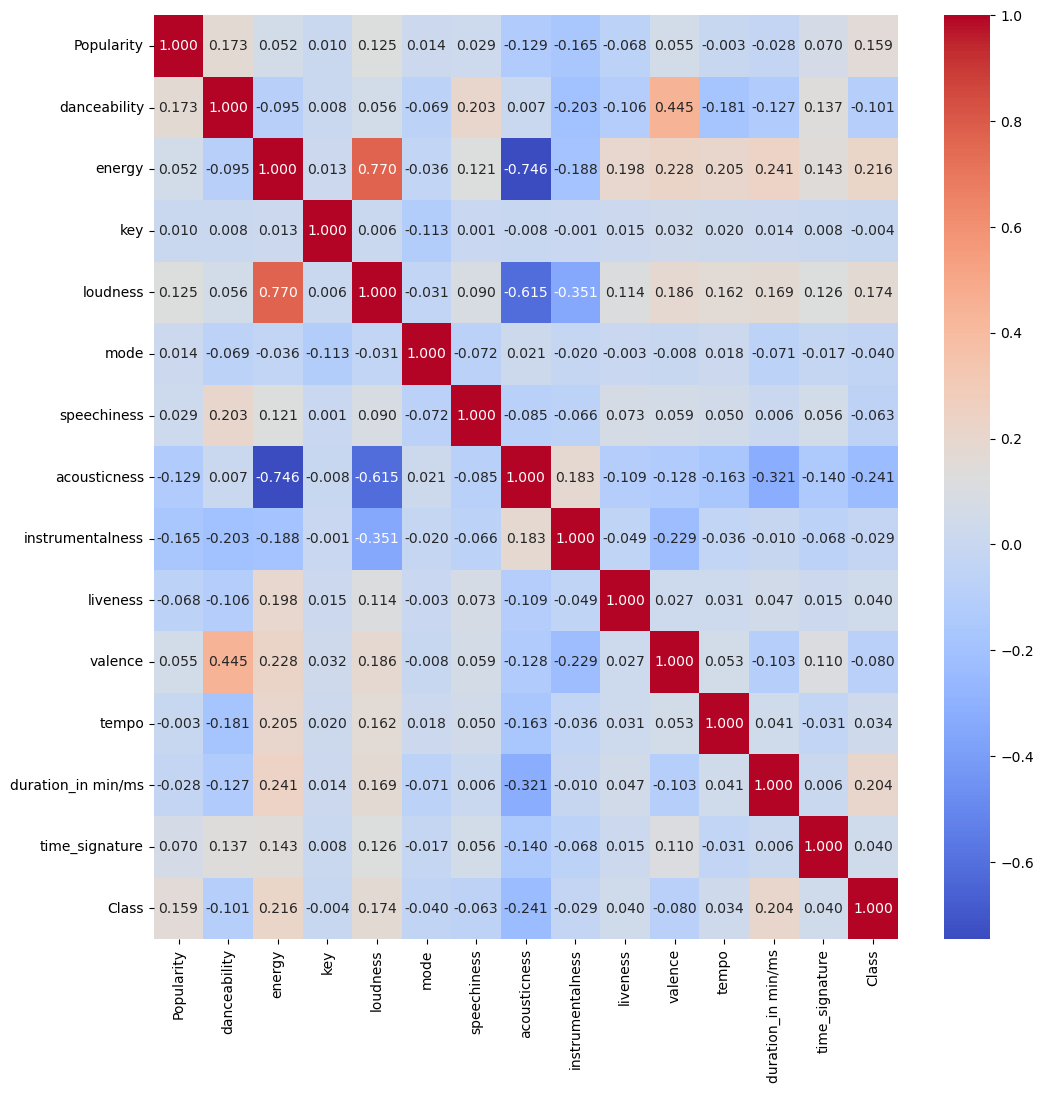

In [15]:
fig = plt.figure(figsize=(12, 12))
sns.heatmap(correlations, annot=True, cmap='coolwarm', fmt=".3f")

# Kết thúc